# Citi Bike Station Demand - Model Results

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().resolve()
if not (project_root / "src").exists() and (project_root / ".." / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import preprocess
from simulate_docks import simulate_inventory, label_risk
from features import build_features
from models.demand import train_demand_models, train_skforecast_model
from models.risk import train_risk_models
from models.prioritize import compute_priority_score
from evaluate import plot_model_comparison, plot_confusion_matrix, plot_predictions

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# Fetch weather data if not cached
from weather import fetch_and_cache_weather

hourly, station_info = preprocess()
date_range = hourly["hour"].agg(["min", "max"])
fetch_and_cache_weather(
    date_range["min"].strftime("%Y-%m-%d"),
    date_range["max"].strftime("%Y-%m-%d"),
)

hourly = simulate_inventory(hourly, station_info)
hourly = label_risk(hourly)
df = build_features(hourly, target="departures")
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} features, {df['station_id'].nunique()} stations")

Loading raw data...


Cleaning...


Filtering stations...


Aggregating to hourly...


Saved 56168 hourly records for 30 stations.
Loading cached weather data from /mnt/c/Hungary/2nd sem/ML/citibike-ml/data/processed/weather.parquet


Adding temporal features...
Adding lag features...
Adding rolling features...


Adding trend features...
Adding cross-station features...


Adding weather features...
Adding station encoding features...


Feature matrix shape: (51128, 53)
Dataset: 51128 rows, 53 features, 30 stations


## Task 1: Station-Level Demand Forecasting

In [3]:
demand_results = train_demand_models(df, target="departures")
sk_result = train_skforecast_model(df, target="departures")
demand_results.append(sk_result)

demand_df = pd.DataFrame(demand_results)
demand_df[["model", "MAE", "RMSE", "R2"]].style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "R2": "{:.3f}"})

Training Ridge...
Training RandomForest...


Training XGBoost...


Training skforecast ForecasterRecursiveMultiSeries...


  skforecast-MultiSeries  MAE=3.6677  RMSE=5.6365


,model,MAE,RMSE,R2
0,Naive,5.646,8.928,0.477
1,HistAvg,7.139,11.337,0.157
2,Ridge,4.456,7.048,0.674
3,RandomForest,4.088,6.744,0.702
4,XGBoost,3.958,6.525,0.721
5,skforecast-MultiSeries,3.668,5.637,0.788


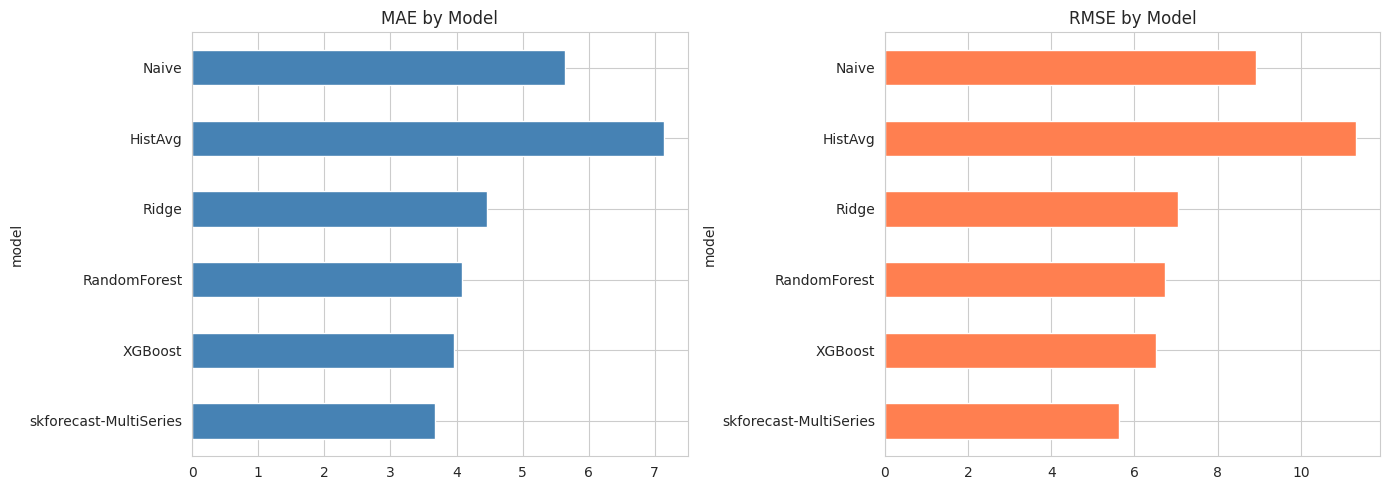

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.DataFrame(demand_results).plot(x="model", y="MAE", kind="barh", ax=axes[0], legend=False, color="steelblue")
axes[0].set_title("MAE by Model")
axes[0].invert_yaxis()

pd.DataFrame(demand_results).plot(x="model", y="RMSE", kind="barh", ax=axes[1], legend=False, color="coral")
axes[1].set_title("RMSE by Model")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("results_demand_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Best sklearn model: XGBoost (MAE=3.958)
Best overall: skforecast-MultiSeries (MAE=3.668)


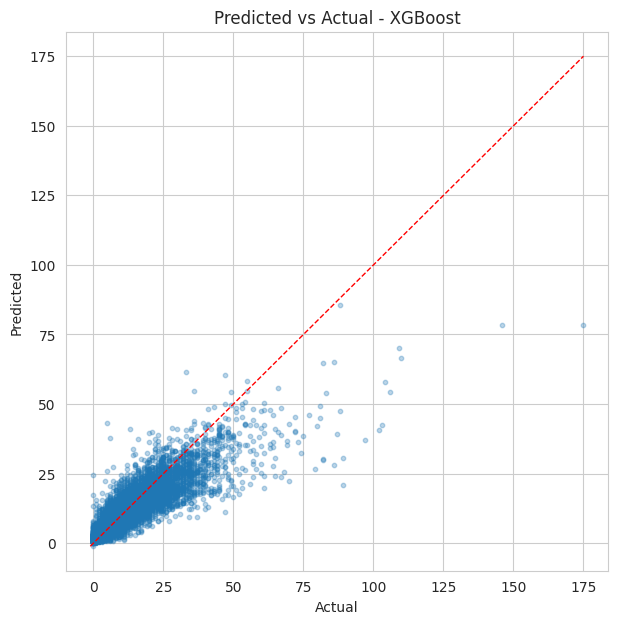

In [5]:
# Find best sklearn model (skforecast has different predict API)
sklearn_results = [r for r in demand_results if r["model"] not in ("Naive", "HistAvg", "skforecast-MultiSeries")]
best = min(sklearn_results, key=lambda r: r["MAE"])
print(f"Best sklearn model: {best['model']} (MAE={best['MAE']:.3f})")

best_overall = min(demand_results, key=lambda r: r["MAE"] if r["model"] not in ("Naive", "HistAvg") else 999)
print(f"Best overall: {best_overall['model']} (MAE={best_overall['MAE']:.3f})")

if "model_obj" in best:
    from models.demand import time_split, FEATURE_COLS_DEMAND
    _, _, test = time_split(df)
    avail = [c for c in FEATURE_COLS_DEMAND if c in df.columns]
    y_pred = best["model_obj"].predict(test[avail])
    fig = plot_predictions(test["departures"], y_pred, title=f"Predicted vs Actual - {best['model']}")
    plt.savefig("results_demand_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()

## Task 2: Station Risk Classification

In [6]:
risk_results = train_risk_models(df, target="is_high_risk")

risk_df = pd.DataFrame(risk_results)
risk_df[["model", "Accuracy", "F1"]].style.format({"Accuracy": "{:.3f}", "F1": "{:.3f}"})

Training LogisticRegression...


  Optimal threshold: 0.85
Training RandomForest...


  Optimal threshold: 0.25


Training XGBoost...


  Optimal threshold: 0.45


,model,Accuracy,F1
0,LogisticRegression,0.777,0.429
1,RandomForest,0.888,0.590
2,XGBoost,0.872,0.577


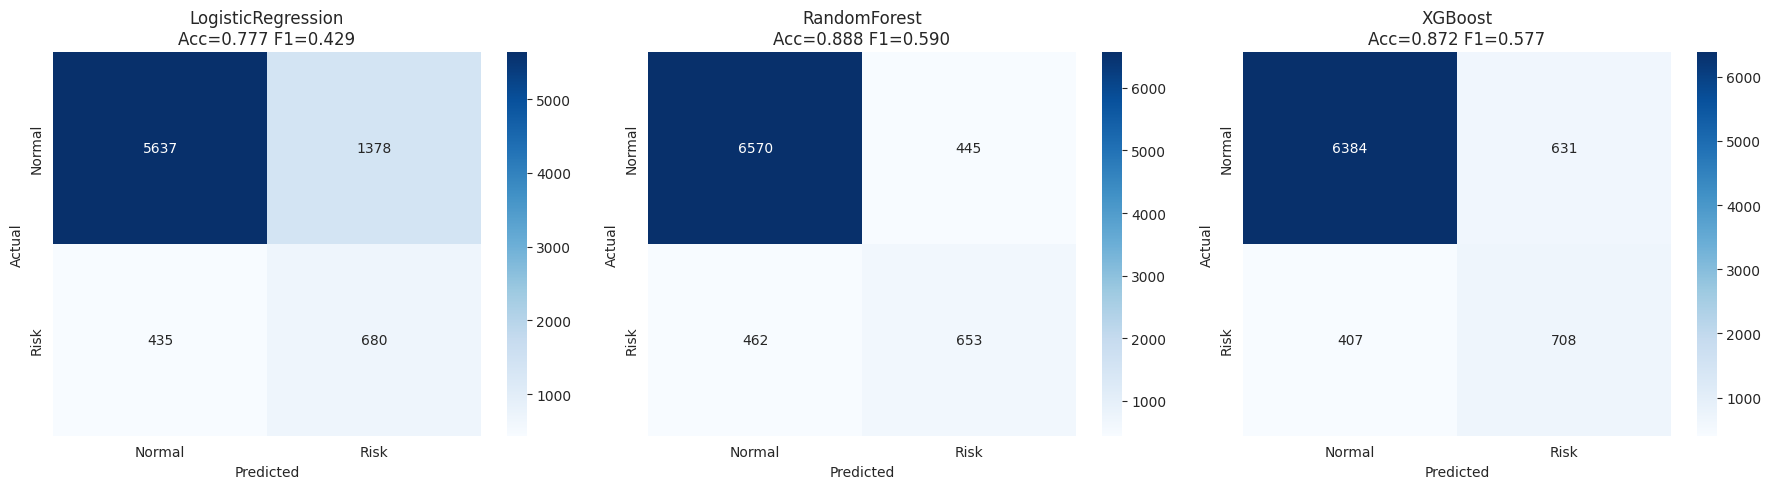

In [7]:
fig, axes = plt.subplots(1, len(risk_results), figsize=(6 * len(risk_results), 5))
if len(risk_results) == 1:
    axes = [axes]

for ax, r in zip(axes, risk_results):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(r["y_test"], r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Risk"], yticklabels=["Normal", "Risk"])
    ax.set_title(f"{r['model']}\nAcc={r['Accuracy']:.3f} F1={r['F1']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("results_risk_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 3: Capacity Prioritization

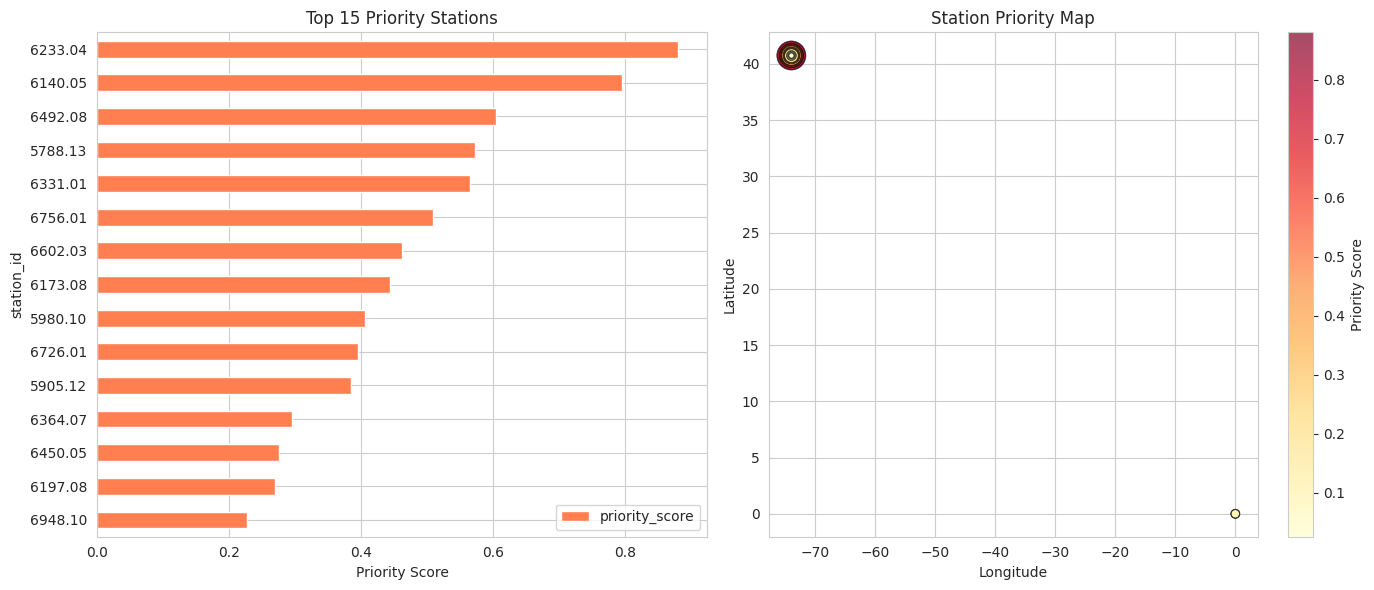


Top 10 Priority Stations:
station_id  priority_score  predicted_demand  risk_frequency
   6233.04        0.880046         13.937790        0.180013
   6140.05        0.795364         12.616259        0.166572
   6492.08        0.604446         10.144936        0.194994
   5788.13        0.572957         10.830716        0.141943
   6331.01        0.564348          9.938798        0.172678
   6756.01        0.508334          8.270833        0.238739
   6602.03        0.462442          8.108363        0.226737
   6173.08        0.444089          8.988943        0.175676
   5980.10        0.405724          9.356849        0.125808
   6726.01        0.395798          9.173121        0.124146


In [8]:
summary = df.groupby("station_id").agg(
    predicted_demand=("departures", "mean"),
    risk_frequency=("is_high_risk", "mean"),
    avg_daily_demand=("departures", lambda x: x.sum() / df.loc[x.index, "hour"].dt.date.nunique()),
    lat=("latitude", "first"),
    lon=("longitude", "first"),
).reset_index()

ranked = compute_priority_score(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ranked.head(15).plot(x="station_id", y="priority_score", kind="barh", ax=axes[0], color="coral")
axes[0].set_title("Top 15 Priority Stations")
axes[0].set_xlabel("Priority Score")
axes[0].invert_yaxis()

scatter = axes[1].scatter(
    ranked["lon"], ranked["lat"],
    c=ranked["priority_score"], cmap="YlOrRd",
    s=ranked["priority_score"] * 500,
    alpha=0.7, edgecolors="black", linewidth=0.5,
)
plt.colorbar(scatter, label="Priority Score", ax=axes[1])
axes[1].set_title("Station Priority Map")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("results_prioritization.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 Priority Stations:")
print(ranked[["station_id", "priority_score", "predicted_demand", "risk_frequency"]].head(10).to_string(index=False))

## Summary

In [9]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"\nTask 1 - Demand Forecasting:")
print(f"  Best sklearn model: {best['model']}")
print(f"  MAE: {best['MAE']:.3f}, RMSE: {best['RMSE']:.3f}, MAPE: {best['MAPE']:.1f}%")
print(f"  Best overall: {best_overall['model']}")
print(f"  MAE: {best_overall['MAE']:.3f}, RMSE: {best_overall['RMSE']:.3f}")

best_risk = max(risk_results, key=lambda r: r["F1"])
print(f"\nTask 2 - Risk Classification:")
print(f"  Best model: {best_risk['model']}")
print(f"  Accuracy: {best_risk['Accuracy']:.3f}, F1: {best_risk['F1']:.3f}")
print(f"  Precision: {best_risk['Precision']:.3f}, Recall: {best_risk['Recall']:.3f}")

print(f"\nTask 3 - Top Priority Station: {ranked.iloc[0]['station_id']}")
print(f"  Priority Score: {ranked.iloc[0]['priority_score']:.3f}")
print(f"  Avg Daily Demand: {ranked.iloc[0]['avg_daily_demand']:.1f}")
print(f"  Risk Frequency: {ranked.iloc[0]['risk_frequency']:.3f}")

RESULTS SUMMARY

Task 1 - Demand Forecasting:
  Best sklearn model: XGBoost
  MAE: 3.958, RMSE: 6.525, MAPE: 44.4%
  Best overall: skforecast-MultiSeries
  MAE: 3.668, RMSE: 5.637

Task 2 - Risk Classification:
  Best model: RandomForest
  Accuracy: 0.888, F1: 0.590
  Precision: 0.595, Recall: 0.586

Task 3 - Top Priority Station: 6233.04
  Priority Score: 0.880
  Avg Daily Demand: 260.0
  Risk Frequency: 0.180
